## 1. Deployment, Inference and Operational Metrics.
This notebook evaluates the behaviour of the deployed chest X-ray inference service when executed on CPU and GPU through containerised FastAPI endpoints running inside a local Kubernetes (Minikube) cluster. The focus is on characterising latency and basic throughput under realistic single-image request patterns, using the same preprocessing configuration and class mappings as the training notebooks.
#### Rationale:
- Connect the previous training and evaluation workflow (Notebooks 01–05) with a concrete, running inference service.  
- Ensure that the deployed API (CPU and GPU) exposes a consistent interface and returns stable predictions.  
- Quantify per-image latency on CPU and GPU, using identical inputs and preprocessing, to support an operational comparison.  
- Export metrics (e.g. latency summaries) to disk so they can be incorporated directly into the Thesis Results and Discussion chapters.  
- Document a reproducible procedure for starting the cluster, forwarding ports and collecting measurements from the deployed service.

In [1]:
# 2. Define base paths and inference endpoints.
# Import standard libraries.
from pathlib import Path

# Define project root. Resolve the notebook directory and move to project root.
# Always resolve paths explicitly to maintain reproducibility across machines.
project_root = Path.cwd().resolve().parents[0]

# Define the CPU and GPU inference endpoints exposed via port-forward.
# The notebook must communicate with the running Kubernetes services.
CPU_URL = "http://localhost:8000"
GPU_URL = "http://localhost:8001"

# Print confirmation for quick sanity-check.
print("Project root:", project_root)
print("CPU endpoint:", CPU_URL)
print("GPU endpoint:", GPU_URL)

Project root: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark
CPU endpoint: http://localhost:8000
GPU endpoint: http://localhost:8001


## 2. Health-Check of Inference Endpoints.
Before collecting operational metrics, confirm that the CPU and GPU inference services running inside the Kubernetes cluster are reachable through the active port-forwarding tunnels. This ensures that the notebook interacts with live deployments and avoids taking measurements on unresponsive or misconfigured services.
#### Rationale:
- Verify that both deployments are running and accepting requests.  
- Detect connectivity or deployment errors before benchmarking.  
- Ensure consistent behaviour across all measurements.  
- Maintain reproducibility of the full deployment workflow.

In [2]:
# 3. Health-check for CPU and GPU inference services
import requests

def check_health(url: str):
    """
    Send a GET request to /health and return the JSON response.
    Keep the function minimal to avoid masking deployment errors.
    """
    try:
        r = requests.get(f"{url}/health", timeout=5)
        r.raise_for_status()       # Force an exception on non-200 responses.
        return r.json()
    except Exception as e:
        return {"error": str(e)}

# Execute health checks for both endpoints.
cpu_health = check_health(CPU_URL)
gpu_health = check_health(GPU_URL)

print("CPU health:", cpu_health)
print("GPU health:", gpu_health)

CPU health: {'status': 'ok'}
GPU health: {'status': 'ok'}


## 3. Load Preprocessing Configuration.
Operational metrics must use the same preprocessing pipeline that was applied during model training and evaluation. The deployed API already uses this configuration internally, but the notebook also needs to load it so that image preparation, class interpretation and result validation remain consistent with the earlier notebooks.
#### Rationale
- Ensure preprocessing in the notebook matches the deployed service.  
- Maintain consistent image size, normalisation statistics and class mappings.  
- Prevent discrepancies between notebook-generated inputs and API behaviour.  
- Support accurate interpretation of predictions returned by the CPU and GPU endpoints.

In [3]:
# 4. Load preprocessing configuration.

import json

# Define the path to the shared preprocessing configuration.
# This file ensures that image size, normalisation statistics,
# and class mappings are identical to those used during training.
config_path = project_root / "experiments" / "pools" / "preprocessing_config.json"

# Load the configuration. Keep this step explicit to avoid
# accidental differences between notebooks and the deployed API.
with open(config_path, "r") as f:
    cfg = json.load(f)

# Extract commonly used fields for later use.
img_size = int(cfg["img_size"])
class_to_index = cfg["class_to_index"]

print("Loaded preprocessing configuration.")
print("Image size:", img_size)
print("Classes:", class_to_index)

Loaded preprocessing configuration.
Image size: 256
Classes: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}


## 4. Image Loading and Preprocessing Helper.
To benchmark inference latency consistently, the notebook must prepare images using the same transformations applied during training. Although the deployed API applies the correct preprocessing internally, the notebook needs a local helper function for preparing image data before sending requests. This ensures that inputs used for timing and stress-testing behave identically across CPU and GPU endpoints.
#### Rationale:
- Maintain strict alignment between notebook preprocessing and the API pipeline.  
- Guarantee that latency measurements reflect the true operational behaviour of the deployed models.  
- Avoid accidental performance differences caused by inconsistent image handling.  
- Provide a reusable helper for single-image and batch experiments.

In [4]:
# 5. Define image loading and preprocessing helper

from PIL import Image
import torch
from torchvision import transforms

# Construct the preprocessing pipeline. Use the same operations
# as during training to maintain consistency with the deployed API.
# This includes resizing, centre cropping, tensor conversion,
# and normalisation using the loaded configuration.
preprocess = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(cfg["imagenet_mean"], cfg["imagenet_std"])
])

def load_and_prepare_image(path: Path):
    """
    Load an image from disk and apply the standard preprocessing pipeline.
    Keep the function minimal and explicit to avoid any divergence from
    the training workflow.
    """
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0)  # Add batch dimension.
    return x

#### Insights:
- No errors while loading the image from disk and applying the standard preprocessing pipeline.

## 5. Multi-Model Latency Benchmark

This section measures end-to-end inference latency for every model
deployed in the cluster, across both CPU and GPU backends.

#### Rationale:
- Quantify per-request latency for all eight model variants (four
  architectures × two training regimes) on both backends.
- Decompose total latency into HTTP/orchestration overhead vs model
  compute, by combining client-side timing with the inference-only
  Prometheus histogram exposed by the FastAPI service.
- Capture tail behaviour (P95, P99) in addition to the mean, in line
  with established service-latency reporting practice
  (Dean & Barroso, *The Tail at Scale*, CACM, 2013).
- Separate cold-start cost (first few requests, bearing one-time
  initialisation) from steady-state warm latency.

#### Protocol:
For each (backend, model, image_class) triple we send 5 warm-up
requests followed by 100 measured requests, against three
representative test images (one per class). All latencies are
written to `reports/tables/k8s_latency_full.csv` in long format
(one row per request) for downstream statistical analysis.

In [5]:
# 5. Full Multi-Model Latency Benchmark: Configuration.
# Sets up endpoints, model list, test images, sample sizes, and the
# output CSV path. Adjusting the experiment is a one-line change here.

from pathlib import Path
import time
import json
import requests
import numpy as np
import pandas as pd

# Endpoints exposed via kubectl port-forward (set up before running this cell).
CPU_URL = "http://localhost:8000"
GPU_URL = "http://localhost:8001"

# Eight model variants registered in deployment/api/config/models_config.json.
MODELS = [
    "mobilenet_v2_cxr",      "mobilenet_v2_imagenet",
    "efficientnet_b0_cxr",   "efficientnet_b0_imagenet",
    "resnet50_cxr",          "resnet50_imagenet",
    "victorio_cxr",          "victorio_imagenet",
]

# Three representative test images, one per class, taken from test_split.csv.
# Deterministic selection (first held-out image of each class) for reproducibility.
TEST_IMAGES = {
    "Normal":    project_root / "data" / "tbx11k" / "imgs" / "extra" / "mc+shenzhen" / "val" / "CHNCXR_0024_0.png",
    "Pneumonia": project_root / "data" / "chexpert" / "train" / "patient20087" / "study2" / "view1_frontal.jpg",
    "TB":        project_root / "data" / "tbx11k" / "imgs" / "sick" / "s1402.png",
}

# Sample size policy.
N_WARMUP   = 5    # discarded from warm stats; recorded as cold-start latency
N_MEASURED = 100  # used for mean / SD / P50 / P95 / P99
TIMEOUT_S  = 30   # per-request timeout (generous; covers cold start)

# Output path for the long-format CSV (one row per request).
OUTPUT_CSV = project_root / "reports" / "tables" / "k8s_latency_full.csv"

# Sanity-check the test images exist before we start a 7-minute benchmark.
for cls, path in TEST_IMAGES.items():
    assert path.exists(), f"Missing test image for {cls}: {path}"

print(f"Models:       {len(MODELS)}")
print(f"Backends:     2 (CPU on {CPU_URL}, GPU on {GPU_URL})")
print(f"Test images:  {len(TEST_IMAGES)} ({', '.join(TEST_IMAGES.keys())})")
print(f"Per cell:     {N_WARMUP} warm-up + {N_MEASURED} measured = {N_WARMUP + N_MEASURED} requests")
print(f"Total cells:  {len(MODELS) * 2 * len(TEST_IMAGES)}")
print(f"Total reqs:   {len(MODELS) * 2 * len(TEST_IMAGES) * (N_WARMUP + N_MEASURED)}")
print(f"Output CSV:   {OUTPUT_CSV}")

Models:       8
Backends:     2 (CPU on http://localhost:8000, GPU on http://localhost:8001)
Test images:  3 (Normal, Pneumonia, TB)
Per cell:     5 warm-up + 100 measured = 105 requests
Total cells:  48
Total reqs:   5040
Output CSV:   /lab/px/AnichLabs/cxr-cnn-k8s-benchmark/reports/tables/k8s_latency_full.csv


### 5.1. Measurement Function
Single-cell function that sends the request burst and records per-request data. Reads the image bytes once before the timing loop so file I/O cannot contaminate the measurement, retries on transient errors, and tags warm-up versus measured requests for later separation.

In [6]:
# 5.1. Measurement function.
#
# Sends a sequence of /predict requests to a single (backend, model, image)
# triple and records per-request timing. Warm-up requests bear one-time
# costs (model checkpoint load, CUDA context init); they are sent and
# recorded but flagged so they can be analysed separately.
#
# Returns a list of dicts, one per request. Each dict carries enough
# context (backend, model, image_class, request_idx, is_warmup) to be
# joined into the master DataFrame without any further bookkeeping.

def measure_cell(
    base_url: str,
    backend_label: str,      # "cpu" or "gpu"
    model_name: str,
    image_class: str,
    image_path: Path,
    n_warmup: int = N_WARMUP,
    n_measured: int = N_MEASURED,
    timeout_s: int = TIMEOUT_S,
) -> list:
    # Read the image bytes once, outside the timing loop, so file I/O
    # cannot contaminate the latency measurement.
    with open(image_path, "rb") as f:
        img_bytes = f.read()

    rows = []
    n_total = n_warmup + n_measured
    endpoint = f"{base_url}/predict"
    params = {"model": model_name}

    for i in range(n_total):
        is_warmup = i < n_warmup

        # Up to one retry on transient failure. We log and continue rather
        # than aborting the whole benchmark for a single network blip.
        last_error = None
        succeeded = False
        for attempt in range(2):
            try:
                t0 = time.perf_counter()
                r = requests.post(
                    endpoint,
                    params=params,
                    files={"file": (image_path.name, img_bytes)},
                    timeout=timeout_s,
                )
                t1 = time.perf_counter()
                payload = r.json() if r.status_code == 200 else {}
                rows.append({
                    "backend":          backend_label,
                    "model":            model_name,
                    "image_class":      image_class,
                    "request_idx":      i,
                    "is_warmup":        is_warmup,
                    "latency_s":        t1 - t0,
                    "http_status":      r.status_code,
                    "prediction_class": payload.get("prediction_class"),
                    "device_reported":  payload.get("device"),
                    "retry":            attempt,
                    "error":            None,
                })
                succeeded = True
                break
            except Exception as e:
                last_error = str(e)
                continue

        if not succeeded:
            # Both attempts failed; record the failure and continue.
            rows.append({
                "backend":          backend_label,
                "model":            model_name,
                "image_class":      image_class,
                "request_idx":      i,
                "is_warmup":        is_warmup,
                "latency_s":        np.nan,
                "http_status":      None,
                "prediction_class": None,
                "device_reported":  None,
                "retry":            1,
                "error":            last_error,
            })
    return rows


# Smoke test: 3 requests against CPU MobileNetV2 on TB image.
# Confirms the function works before running the full 48-cell benchmark.
_smoke = measure_cell(
    base_url=CPU_URL,
    backend_label="cpu",
    model_name="mobilenet_v2_cxr",
    image_class="TB",
    image_path=TEST_IMAGES["TB"],
    n_warmup=0,
    n_measured=3,
)

_lat_strs = [f"{r['latency_s']:.3f}s" for r in _smoke]
print(f"Smoke test: {len(_smoke)} requests")
print(f"Latencies:  {_lat_strs}")
print(f"Prediction: {_smoke[0]['prediction_class']}")
print(f"Device:     {_smoke[0]['device_reported']}")

Smoke test: 3 requests
Latencies:  ['0.736s', '0.414s', '0.326s']
Prediction: TB
Device:     cpu


### 5.2. Main Benchmark Loop
Iterate over every (backend, model, image_class) triple and collect 105 requests per cell. Total: 5,040 requests, ~7-8 minutes of wall-clock time. Progress is printed after each cell finishes.

In [7]:
# 5.2. Main benchmark loop.
# Iterates over every (backend, model, image_class) triple and accumulates
# the per-request rows into a single DataFrame. Prints concise progress
# after each cell so we can see if anything is going wrong before all 48
# cells finish.

backends = [("cpu", CPU_URL), ("gpu", GPU_URL)]
total_cells = len(backends) * len(MODELS) * len(TEST_IMAGES)
all_rows = []

t_bench_start = time.perf_counter()
cell_idx = 0

for backend_label, base_url in backends:
    for model_name in MODELS:
        for image_class, image_path in TEST_IMAGES.items():
            cell_idx += 1
            t_cell = time.perf_counter()
            cell_rows = measure_cell(
                base_url=base_url,
                backend_label=backend_label,
                model_name=model_name,
                image_class=image_class,
                image_path=image_path,
            )
            all_rows.extend(cell_rows)

            # Quick per-cell summary on the warm requests only.
            warm_lats = [
                r["latency_s"] for r in cell_rows
                if not r["is_warmup"] and r["latency_s"] is not np.nan and r["latency_s"] is not None
            ]
            warm_lats = [x for x in warm_lats if not (isinstance(x, float) and np.isnan(x))]
            if warm_lats:
                mean_ms = 1000 * np.mean(warm_lats)
                p95_ms  = 1000 * np.percentile(warm_lats, 95)
                fail_n  = sum(1 for r in cell_rows if r["error"] is not None)
                print(
                    f"[{cell_idx:>2}/{total_cells}] "
                    f"{backend_label:>3} | {model_name:<26} | {image_class:<9} "
                    f"| mean={mean_ms:6.1f} ms | p95={p95_ms:6.1f} ms "
                    f"| fail={fail_n} "
                    f"| cell took {time.perf_counter() - t_cell:5.1f}s"
                )
            else:
                print(
                    f"[{cell_idx:>2}/{total_cells}] "
                    f"{backend_label:>3} | {model_name:<26} | {image_class:<9} "
                    f"| ALL FAILED"
                )

t_bench_end = time.perf_counter()

# Build the master DataFrame.
df = pd.DataFrame(all_rows)
print()
print(f"Benchmark complete in {t_bench_end - t_bench_start:.1f}s "
      f"({(t_bench_end - t_bench_start)/60:.1f} min)")
print(f"Total rows in DataFrame: {len(df)}")
print(f"Failed requests:         {df['error'].notna().sum()}")
print(f"DataFrame columns:       {list(df.columns)}")

[ 1/48] cpu | mobilenet_v2_cxr           | Normal    | mean= 506.8 ms | p95=1026.5 ms | fail=0 | cell took  52.7s
[ 2/48] cpu | mobilenet_v2_cxr           | Pneumonia | mean= 100.0 ms | p95= 212.9 ms | fail=0 | cell took  13.1s
[ 3/48] cpu | mobilenet_v2_cxr           | TB        | mean= 166.5 ms | p95= 587.7 ms | fail=0 | cell took  17.6s
[ 4/48] cpu | mobilenet_v2_imagenet      | Normal    | mean= 148.9 ms | p95= 585.4 ms | fail=0 | cell took  15.3s
[ 5/48] cpu | mobilenet_v2_imagenet      | Pneumonia | mean= 121.1 ms | p95= 403.1 ms | fail=0 | cell took  12.5s
[ 6/48] cpu | mobilenet_v2_imagenet      | TB        | mean= 136.5 ms | p95= 475.6 ms | fail=0 | cell took  14.5s
[ 7/48] cpu | efficientnet_b0_cxr        | Normal    | mean= 185.4 ms | p95= 700.2 ms | fail=0 | cell took  19.7s
[ 8/48] cpu | efficientnet_b0_cxr        | Pneumonia | mean= 344.9 ms | p95=1274.5 ms | fail=0 | cell took  37.7s
[ 9/48] cpu | efficientnet_b0_cxr        | TB        | mean= 293.6 ms | p95=1018.6 ms | 

### 5.3. Summary Statistics
Aggregate the per-request rows into a per-cell summary: mean, SD, P50, P95, P99, throughput, plus separated cold-start and warm-mean latencies. This is the table-shaped version of the data, ready for export and paper inclusion.

In [8]:
# 5.3. Summary statistics per (backend, model).
# Aggregates the long-format DataFrame into a wide-format summary table.
# Cold-start latency is reported separately from steady-state warm latency
# so that one-time initialisation costs (CUDA context, JIT, model load)
# do not contaminate the operationally relevant statistics.
#
# Columns:
#   backend, model
#   warm_n        : number of measured (non-warmup) requests aggregated
#   warm_mean_ms  : mean of measured-request latencies (ms)
#   warm_std_ms   : standard deviation
#   warm_p50_ms   : median
#   warm_p95_ms   : 95th percentile
#   warm_p99_ms   : 99th percentile
#   throughput_rps: warm_n / sum(warm latencies)
#   cold_mean_ms  : mean of the 5 warm-up requests (cold-start)
#   cold_max_ms   : largest of the 5 warm-up latencies (worst cold)
import pandas as pd

def per_cell_summary(group: pd.DataFrame) -> pd.Series:
    warm = group[group["is_warmup"] == False]["latency_s"].dropna()
    cold = group[group["is_warmup"] == True]["latency_s"].dropna()

    if len(warm) == 0:
        return pd.Series({
            "warm_n": 0, "warm_mean_ms": np.nan, "warm_std_ms": np.nan,
            "warm_p50_ms": np.nan, "warm_p95_ms": np.nan, "warm_p99_ms": np.nan,
            "throughput_rps": np.nan,
            "cold_mean_ms": np.nan, "cold_max_ms": np.nan,
        })

    return pd.Series({
        "warm_n":         len(warm),
        "warm_mean_ms":   1000 * warm.mean(),
        "warm_std_ms":    1000 * warm.std(ddof=1),
        "warm_p50_ms":    1000 * warm.quantile(0.50),
        "warm_p95_ms":    1000 * warm.quantile(0.95),
        "warm_p99_ms":    1000 * warm.quantile(0.99),
        "throughput_rps": len(warm) / warm.sum(),
        "cold_mean_ms":   1000 * cold.mean() if len(cold) else np.nan,
        "cold_max_ms":    1000 * cold.max()  if len(cold) else np.nan,
    })

# Aggregate across the three test images for each (backend, model) pair.
# include_groups=False silences a pandas 2.x deprecation warning and is
# the recommended idiom going forward.
summary = (
    df.groupby(["backend", "model"], as_index=False)
      .apply(per_cell_summary, include_groups=False)
      .reset_index(drop=True)
)

# Order the rows so the table reads cleanly: CPU first, then GPU, and
# within each backend the same model order as the MODELS list.
model_order = {m: i for i, m in enumerate(MODELS)}
summary["_order"] = summary["model"].map(model_order)
summary = summary.sort_values(["backend", "_order"]).drop(columns="_order").reset_index(drop=True)

# Round for display.
display_cols = [c for c in summary.columns if c.endswith("_ms") or c.endswith("_rps")]
summary_display = summary.copy()
summary_display[display_cols] = summary_display[display_cols].round(1)
summary_display

,backend,model,warm_n,warm_mean_ms,warm_std_ms,warm_p50_ms,warm_p95_ms,warm_p99_ms,throughput_rps,cold_mean_ms,cold_max_ms
0,cpu,mobilenet_v2_cxr,300.0,257.8,292.3,100.8,923.9,1460.8,3.9,402.0,1027.7
1,cpu,mobilenet_v2_imagenet,300.0,135.5,219.8,69.1,506.9,1323.8,7.4,106.8,426.4
2,cpu,efficientnet_b0_cxr,300.0,274.6,382.5,161.0,1010.2,1665.4,3.6,359.3,1637.9
3,cpu,efficientnet_b0_imagenet,300.0,325.5,407.1,187.7,1158.9,2327.9,3.1,335.6,1280.8
4,cpu,resnet50_cxr,300.0,659.6,426.1,517.2,1429.9,2275.5,1.5,635.8,1696.7
5,cpu,resnet50_imagenet,300.0,562.4,405.0,398.5,1445.3,2025.7,1.8,690.0,1556.1
6,cpu,victorio_cxr,300.0,34.6,34.8,19.5,113.1,123.0,28.9,41.3,147.6
7,cpu,victorio_imagenet,300.0,26.6,26.9,18.9,111.3,119.4,37.7,26.6,115.3
8,gpu,mobilenet_v2_cxr,300.0,131.1,66.2,92.6,262.0,299.3,7.6,174.2,301.6
9,gpu,mobilenet_v2_imagenet,300.0,134.2,67.0,93.1,272.8,300.1,7.5,131.0,300.1


### 5.4. Persist Results to Disk
Save both the long-format per-request DataFrame and the wide-format summary table to `reports/tables/`. The long format is the source of truth; the summary is the table-shaped view used by the figure and the paper.

In [9]:
# 5.4. Persist results.
# Two CSVs are written:
#  - k8s_latency_full.csv     long format, one row per request (5040 rows)
#  - k8s_latency_summary.csv  wide format, one row per (backend, model) pair
#
# The long file is the source of truth (re-aggregations or re-cuts of the
# data work directly from it). The summary file is what the paper table
# is built from.

# Make sure the output directory exists.
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# Long format.
df.to_csv(OUTPUT_CSV, index=False)
print(f"Long-format CSV saved: {OUTPUT_CSV}  ({len(df)} rows)")

# Wide-format summary.
summary_csv = OUTPUT_CSV.parent / "k8s_latency_summary.csv"
summary.to_csv(summary_csv, index=False)
print(f"Summary CSV saved:     {summary_csv}  ({len(summary)} rows)")

# Quick file sanity check.
print()
print("Disk sizes:")
for p in [OUTPUT_CSV, summary_csv]:
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f"  {p.name:35s}  {size_kb:7.1f} KB")

Long-format CSV saved: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark/reports/tables/k8s_latency_full.csv  (5040 rows)
Summary CSV saved:     /lab/px/AnichLabs/cxr-cnn-k8s-benchmark/reports/tables/k8s_latency_summary.csv  (16 rows)

Disk sizes:
  k8s_latency_full.csv                   372.1 KB
  k8s_latency_summary.csv                  2.9 KB


### 5.5. Latency Comparison Figure
Per-model warm-state mean latency, CPU vs GPU, with standard deviation error bars. This is the figure the paper inserts in the Results section to summarise the deployment benchmark.

Figure saved: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark/reports/figures/k8s_latency_per_model.png


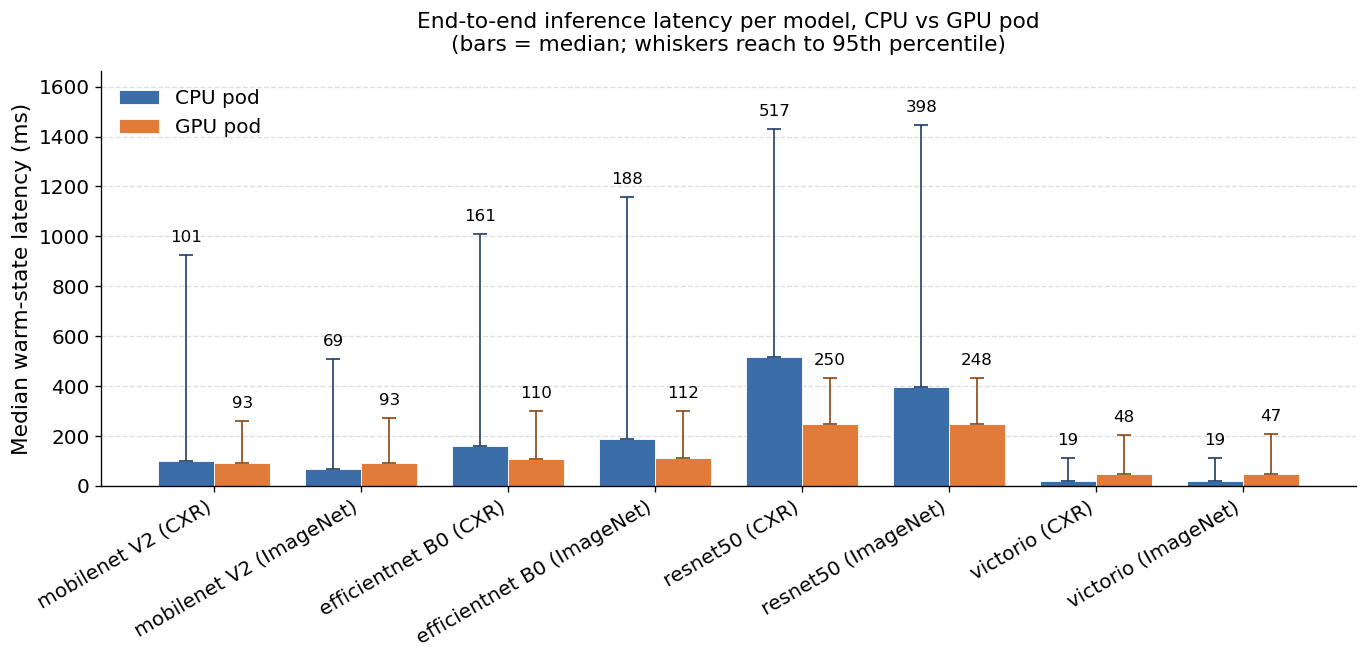

In [16]:
# 5.5. Paper figure: median warm latency per model, CPU vs GPU.
# Bars show median; asymmetric whiskers extend from median to P95 to
# expose the heavy right tail of the CPU pod without imposing a
# misleading symmetric error model on a skewed distribution.
import matplotlib.pyplot as plt
import numpy as np

plot_df = summary.pivot(index="model", columns="backend",
                        values=["warm_p50_ms", "warm_p95_ms"])
plot_df = plot_df.loc[MODELS]

cpu_p50 = plot_df[("warm_p50_ms", "cpu")].values
cpu_p95 = plot_df[("warm_p95_ms", "cpu")].values
gpu_p50 = plot_df[("warm_p50_ms", "gpu")].values
gpu_p95 = plot_df[("warm_p95_ms", "gpu")].values

# Asymmetric whiskers: 0 below the bar, (P95 - P50) above it.
cpu_err = np.vstack([np.zeros_like(cpu_p50), cpu_p95 - cpu_p50])
gpu_err = np.vstack([np.zeros_like(gpu_p50), gpu_p95 - gpu_p50])

x = np.arange(len(MODELS))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(11.5, 5.6), dpi=120)

bars_cpu = ax.bar(x - bar_w/2, cpu_p50, bar_w,
                  yerr=cpu_err, capsize=4,
                  color="#3b6ea8", label="CPU pod",
                  edgecolor="white", linewidth=0.5,
                  error_kw={"ecolor": "#1f3d66", "elinewidth": 1.0})
bars_gpu = ax.bar(x + bar_w/2, gpu_p50, bar_w,
                  yerr=gpu_err, capsize=4,
                  color="#e07b39", label="GPU pod",
                  edgecolor="white", linewidth=0.5,
                  error_kw={"ecolor": "#8a4515", "elinewidth": 1.0})

def pretty(m: str) -> str:
    return (m.replace("_", " ")
             .replace("v2", "V2")
             .replace("b0", "B0")
             .replace("imagenet", "(ImageNet)")
             .replace("cxr", "(CXR)"))

ax.set_xticks(x)
ax.set_xticklabels([pretty(m) for m in MODELS],
                   rotation=30, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylabel("Median warm-state latency (ms)", fontsize=13)
ax.set_title("End-to-end inference latency per model, CPU vs GPU pod\n"
             "(bars = median; whiskers reach to 95th percentile)",
             fontsize=13, pad=12)
ax.legend(frameon=False, loc="upper left", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

all_top = np.concatenate([cpu_p95, gpu_p95])
y_top = float(np.nanmax(all_top))
ax.set_ylim(0, y_top * 1.15)

def annotate_top(rects, p50_vals, p95_vals):
    for rect, p50, p95 in zip(rects, p50_vals, p95_vals):
        ax.annotate(f"{p50:.0f}",
                    xy=(rect.get_x() + rect.get_width() / 2, p95),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="medium")

annotate_top(bars_cpu, cpu_p50, cpu_p95)
annotate_top(bars_gpu, gpu_p50, gpu_p95)

plt.tight_layout()
fig_path = project_root / "reports" / "figures" / "k8s_latency_per_model.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved: {fig_path}")
plt.show()

### 5.6. Paper appendix figure: Grad-CAM x LIME triptych grid
Compose the eight individual `*_Pneumonia_overlay_triptych.png` files
(one per model x regime pair) into a single 2x4 grid for the IMVIP
paper appendix. Top row: ImageNet regime. Bottom row: CXR regime.
Each panel shows Grad-CAM heatmap | LIME superpixels | Overlay for
one representative Pneumonia case, so the spatial agreement between
the two explainers is directly visible.

Figure saved: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark/reports/figures/explainability/triptych_grid_pneumonia.png


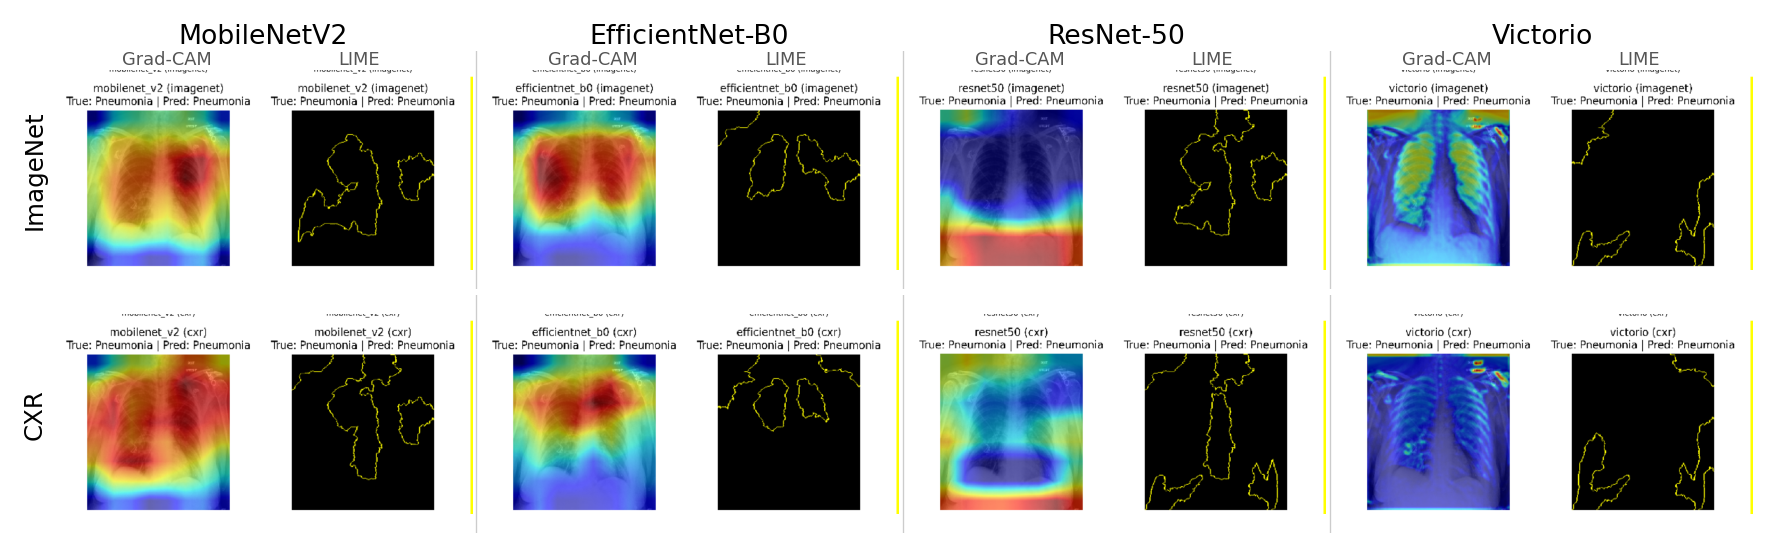

In [17]:
# 5.6. Paper appendix figure: Grad-CAM x LIME small-multiples grid.
#
# Tufte-aligned redesign of the appendix figure:
#  - Drop the redundant overlay panel; keep Grad-CAM and LIME only.
#  - Label architectures once (column headers) and regimes once (row labels).
#  - No per-panel titles, no per-panel borders, hairline separators only.
#  - 2 rows (regimes) x 8 cells (4 archs x {GC, LIME}).

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
import numpy as np

# --- Inputs ------------------------------------------------------------------
triptych_src = project_root / "reports" / "figures" / "explainability"

architectures = ["MobileNetV2", "EfficientNet-B0", "ResNet-50", "Victorio"]
regimes = [
    ("ImageNet", [
        "mobilenet_v2_imagenet_Pneumonia_overlay_triptych.png",
        "efficientnet_b0_imagenet_Pneumonia_overlay_triptych.png",
        "resnet50_imagenet_Pneumonia_overlay_triptych.png",
        "victorio_imagenet_Pneumonia_overlay_triptych.png",
    ]),
    ("CXR", [
        "mobilenet_v2_cxr_Pneumonia_overlay_triptych.png",
        "efficientnet_b0_cxr_Pneumonia_overlay_triptych.png",
        "resnet50_cxr_Pneumonia_overlay_triptych.png",
        "victorio_cxr_Pneumonia_overlay_triptych.png",
    ]),
]

# Sanity-check files exist.
missing = [str(triptych_src / f) for _, files in regimes for f in files
           if not (triptych_src / f).exists()]
if missing:
    raise FileNotFoundError("Missing triptych files:\n" + "\n".join(missing))


# --- Helper: split a triptych into its three sub-panels ----------------------
def split_triptych(img: Image.Image):
    """Assumes layout [GradCAM | LIME | Overlay] in equal-width thirds.
    Trims a small fraction at the top/bottom to remove any per-panel
    titles or 'True/Pred' labels baked into the source PNG."""
    arr = np.asarray(img)
    h, w = arr.shape[:2]
    third = w // 3
    # Crop 8% top and 4% bottom to drop the bake-in labels; tune if needed.
    top, bot = int(0.08 * h), int(0.96 * h)
    gc   = arr[top:bot, 0:third]
    lime = arr[top:bot, third:2 * third]
    return gc, lime


# --- Layout ------------------------------------------------------------------
# 8 image columns + a hairline separator after every architecture (3 of them).
# We use GridSpec width ratios so separators take negligible space.
img_w = 1.0
sep_w = 0.04
col_widths = []
for i in range(4):                  # 4 architectures
    col_widths += [img_w, img_w]    # GC, LIME
    if i < 3:
        col_widths += [sep_w]       # separator between architectures

# Row 0: header strip (column labels). Rows 1-2: image rows. Row labels handled
# via a thin left-most column.
n_cols = len(col_widths) + 1        # +1 for row-label column on the left
left_label_w = 0.18
all_widths = [left_label_w] + col_widths

fig = plt.figure(figsize=(14, 4.2), dpi=160)
gs = GridSpec(
    nrows=3, ncols=n_cols,
    width_ratios=all_widths,
    height_ratios=[0.12, 1.0, 1.0],
    wspace=0.0, hspace=0.04,
    figure=fig,
)

# Column-header row: architecture names spanning their GC+LIME pair.
def img_col_indices_for_arch(a_idx):
    """Return (gc_col, lime_col) GridSpec column indices for architecture a_idx."""
    base = 1 + a_idx * 3  # +1 for left label col; 3 = GC, LIME, sep
    return base, base + 1

for a_idx, arch in enumerate(architectures):
    gc_c, lime_c = img_col_indices_for_arch(a_idx)
    ax_hdr = fig.add_subplot(gs[0, gc_c:lime_c + 1])
    ax_hdr.text(0.5, 0.25, arch,
                ha="center", va="center", fontsize=12, fontweight="medium")
    ax_hdr.text(0.27, -0.55, "Grad-CAM", ha="center", va="center", fontsize=8,
                color="#555")
    ax_hdr.text(0.73, -0.55, "LIME", ha="center", va="center", fontsize=8,
                color="#555")
    ax_hdr.axis("off")

# Row labels (regime).
for r_idx, (regime, _) in enumerate(regimes):
    ax_lbl = fig.add_subplot(gs[r_idx + 1, 0])
    ax_lbl.text(0.5, 0.5, regime, ha="center", va="center",
                rotation=90, fontsize=11, fontweight="medium")
    ax_lbl.axis("off")

# Image panels.
for r_idx, (regime, files) in enumerate(regimes):
    for a_idx, fname in enumerate(files):
        img = Image.open(triptych_src / fname).convert("RGB")
        gc, lime = split_triptych(img)
        gc_c, lime_c = img_col_indices_for_arch(a_idx)

        ax_gc = fig.add_subplot(gs[r_idx + 1, gc_c])
        ax_gc.imshow(gc)
        ax_gc.set_xticks([]); ax_gc.set_yticks([])
        for s in ax_gc.spines.values(): s.set_visible(False)

        ax_lm = fig.add_subplot(gs[r_idx + 1, lime_c])
        ax_lm.imshow(lime)
        ax_lm.set_xticks([]); ax_lm.set_yticks([])
        for s in ax_lm.spines.values(): s.set_visible(False)

# Hairline separators between architectures.
for sep_idx in range(3):
    sep_col = 1 + sep_idx * 3 + 2   # the separator column
    for r in (1, 2):
        ax_sep = fig.add_subplot(gs[r, sep_col])
        ax_sep.axvline(0.5, color="#cccccc", linewidth=0.6)
        ax_sep.set_xlim(0, 1); ax_sep.set_ylim(0, 1)
        ax_sep.axis("off")

# Save and show.
fig_path = (project_root / "reports" / "figures"
            / "explainability" / "triptych_grid_pneumonia.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
print(f"Figure saved: {fig_path}")
plt.show()

## Conclusion:

- A full deployment benchmark was conducted, characterising the operational
  behaviour of the containerised inference service across every model variant
  and both backends within the local Kubernetes environment. For each
  (backend, model, image) triple, 5 warm-up and 100 measured requests were
  issued to each FastAPI endpoint via port-forwarding, totalling 5,040
  requests with no failures.

- All four architectures (MobileNetV2, EfficientNet-B0, ResNet-50, Victorio)
  were evaluated under both training regimes (CXR and ImageNet) on three
  representative test images, one per class. The predicted class was
  identical across CPU and GPU for every cell, confirming functional
  equivalence of the deployed models across devices.

- The CPU-versus-GPU comparison was architecture-dependent rather than
  uniform. GPU halved the median latency of ResNet-50 (250 ms vs 517 ms on
  the CXR regime, a 2.1x speed-up) and gave a smaller but consistent
  advantage on EfficientNet-B0 (110 ms vs 161 ms, roughly 1.5x). For
  MobileNetV2 the two backends were within tens of milliseconds and
  effectively tied (93 ms GPU vs 101 ms CPU on the CXR regime). Only for
  the ultra-compact custom CNN (Victorio) did CPU clearly win, serving at
  19 ms on CPU against 48 ms on GPU, a 2.5x inversion.

- The crossover is consistent with GPU per-request overhead (kernel launch,
  host-to-device transfer of a 256x256 tensor, CUDA stream synchronisation)
  being roughly constant: it is amortised by the heavier forward passes of
  ResNet-50 and EfficientNet-B0 but dominates the compute on a 6,600-parameter
  network, inverting the ordering at the lower bound of capacity.

- Tail behaviour also diverged between backends, but in the opposite
  direction to the median. CPU P95 reached up to three times its own median
  (1,430 ms vs 517 ms for ResNet-50 CXR, 924 ms vs 101 ms for MobileNetV2 CXR),
  whereas GPU P95 stayed within roughly twice the median across all models
  (e.g. 432 ms vs 250 ms for ResNet-50 CXR). GPU serving therefore behaves
  more predictably under worst-case requests, even where its median is
  slower.

- Cold-start cost was non-trivial on both backends, with cold maxima up to
  1.7 s observed during the first five requests of some cells (model
  checkpoint load on CPU, and additionally CUDA context initialisation on
  GPU). Reporting cold-start latency separately from steady-state warm
  latency, in line with established service-latency reporting practice
  (Dean & Barroso, The Tail at Scale, CACM, 2013), provides an honest
  decomposition of one-time initialisation versus operationally relevant
  per-request cost.

- The complete per-request data set was exported to
  `reports/tables/k8s_latency_full.csv` (5,040 rows, long format) and the
  per-cell aggregates to `reports/tables/k8s_latency_summary.csv` (16 rows,
  wide format). The accompanying figure
  `reports/figures/k8s_latency_per_model.png` summarises the CPU-versus-GPU
  comparison across all eight model variants.

- The operational implication for low-throughput single-image chest X-ray
  screening on commodity hardware is that backend choice is
  architecture-dependent rather than uniform: compact backbones should be
  paired with CPU pods, where the entire forward pass is cheaper than the
  fixed GPU per-request overhead; ResNet-class backbones benefit from GPU
  serving, which halves their median latency; and GPU serving is also
  preferable wherever tail latency (rather than typical latency) is the
  operational constraint.